In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

converting our data to data frame just in case if its not

In [2]:
data = pd.read_csv("heart.csv")
df = pd.DataFrame(data)
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


checking for any empty or missing values in rows

In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
df.describe(include="all")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


since this data is supposed to be made with int and float valuse we must check if all samples follow this rule with a simple value check function

In [5]:
def value_ckeck(data,allcol):
    for col in allcol:
        for i in data[col]:
            if type(i) == int or float:
                print(f"all data in {col} column are numerical")
                print("_"*40)
                break
            else:
                print(f"there is a differetn type of value in {col} column ")

In [6]:
columns=["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target"]
value_ckeck(df,columns)

all data in age column are numerical
________________________________________
all data in sex column are numerical
________________________________________
all data in cp column are numerical
________________________________________
all data in trestbps column are numerical
________________________________________
all data in chol column are numerical
________________________________________
all data in fbs column are numerical
________________________________________
all data in restecg column are numerical
________________________________________
all data in thalach column are numerical
________________________________________
all data in exang column are numerical
________________________________________
all data in oldpeak column are numerical
________________________________________
all data in slope column are numerical
________________________________________
all data in ca column are numerical
________________________________________
all data in thal column are numerical
______

all good.we dont have any type of sample other than int and float.now just to be safe lets see if we have duplicated samples 

In [7]:
df.duplicated().sum()

np.int64(1)

as you can see we have 2 samples with same values.but we also need to check it manually to see if they have same values 

In [8]:
df[df.duplicated()].index

Index([164], dtype='int64')

In [9]:
df[df.duplicated(keep=False)].index

Index([163, 164], dtype='int64')

In [10]:
print(df.loc[164])
print('*'*30)
print(df.loc[163])

age          38.0
sex           1.0
cp            2.0
trestbps    138.0
chol        175.0
fbs           0.0
restecg       1.0
thalach     173.0
exang         0.0
oldpeak       0.0
slope         2.0
ca            4.0
thal          2.0
target        1.0
Name: 164, dtype: float64
******************************
age          38.0
sex           1.0
cp            2.0
trestbps    138.0
chol        175.0
fbs           0.0
restecg       1.0
thalach     173.0
exang         0.0
oldpeak       0.0
slope         2.0
ca            4.0
thal          2.0
target        1.0
Name: 163, dtype: float64


now that we checked everything we can remove one of them.i have decided to asign my Data to a new variable because i dont want to modifie the original data

In [11]:
df1=df.drop_duplicates()
df1.duplicated().sum()

np.int64(0)

i decided to showe my data in a pie chart and include both genders who have the disease and not . i wanna try to show the percentage in the chater so  i use crosstab  and sellect the datas i need afterwards i use div to get the exact percentage for every sex and target.

In [12]:
ct=pd.crosstab(df1["sex"],df1["target"])
ct

target,0,1
sex,,
0,24,72
1,114,92


In [13]:
ct_percentage=ct.div(ct.sum(axis=1),axis=0)*100
ct_percentage

target,0,1
sex,,
0,25.000000,75.000000
1,55.339806,44.660194


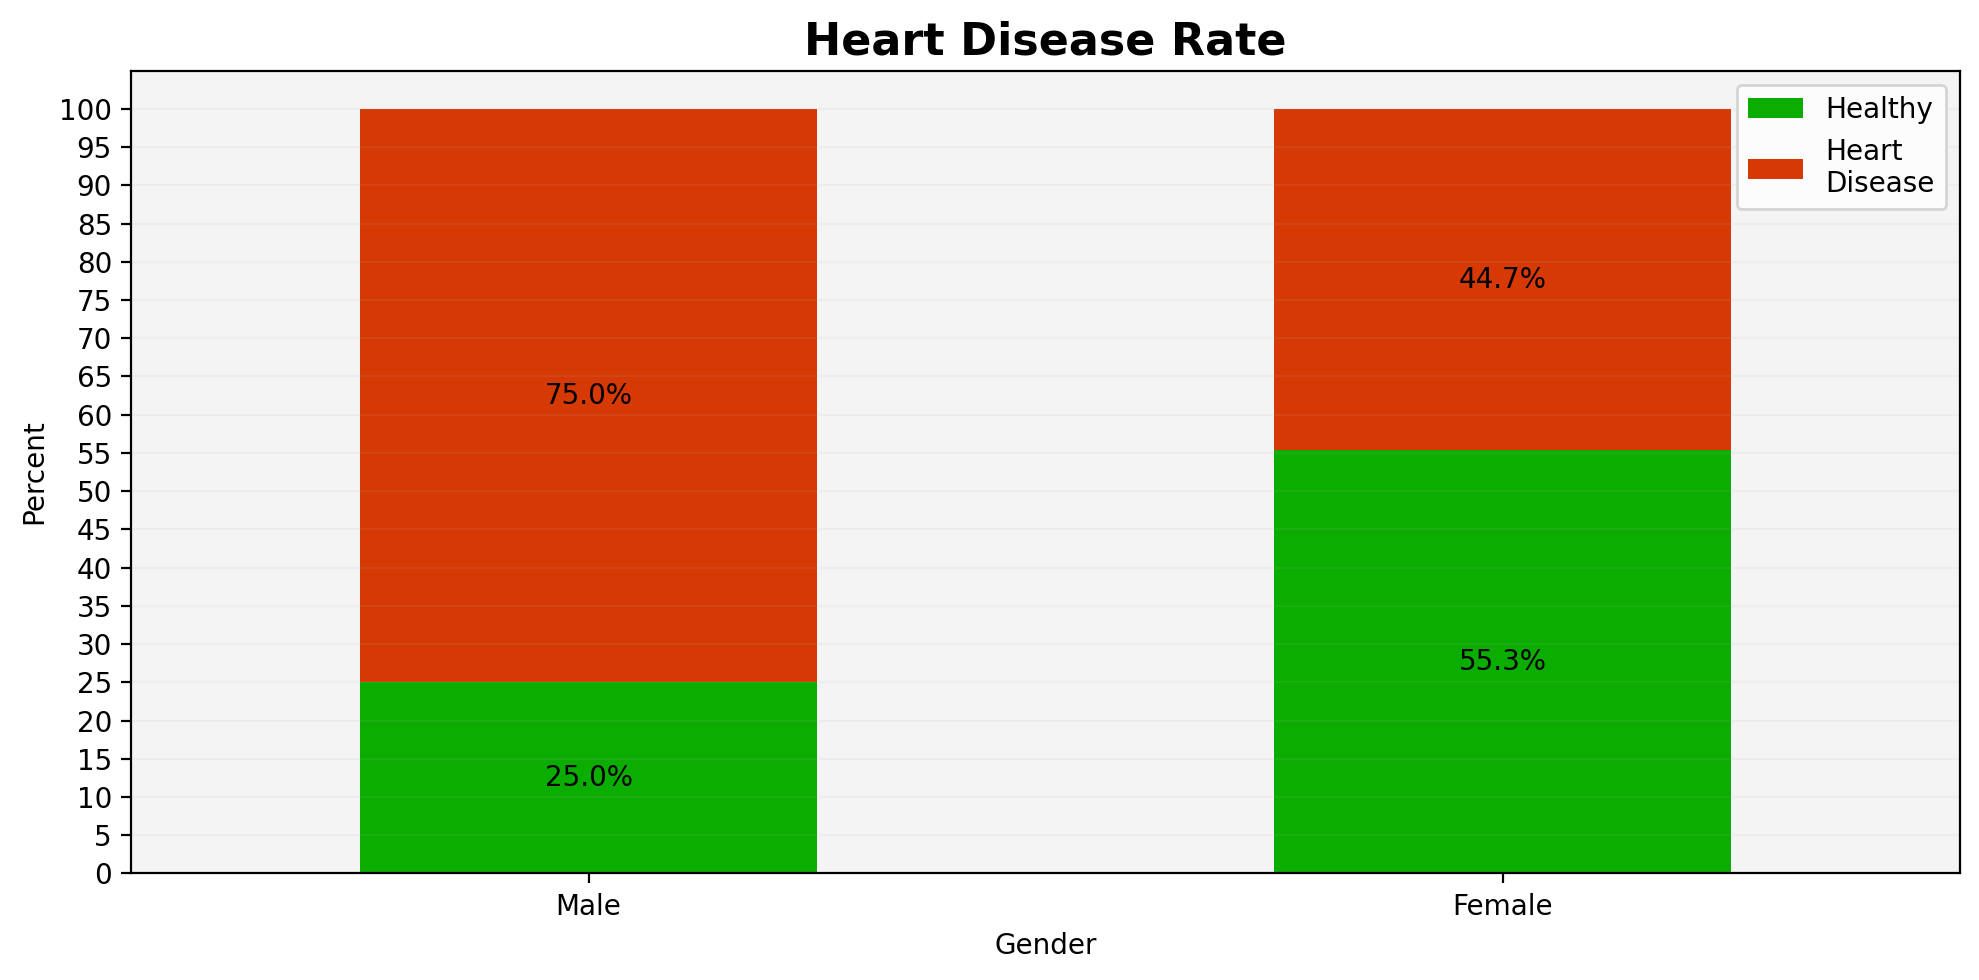

In [14]:
fig,ax=plt.subplots(figsize=(10,5),dpi=200)
ct_percentage.plot(kind="bar",stacked=True,ax=ax,color=["#0BAD00","#D63904"])
ax.set_xlabel("Gender")
ax.set_ylabel("Percent")
ax.set_title("Heart Disease Rate",fontsize=16,fontweight="bold")
ax.set_facecolor("#f4f4f4")
ax.legend(["Healthy","Heart\nDisease"],loc="upper right")
for axs in ax.containers:
    ax.bar_label(axs,label_type='center',fmt='%.1f%%')
ax.set_xticklabels(['Male',"Female"],rotation=0)
ax.set_yticks(range(0,101,5))
ax.grid(True,alpha=0.1,axis='y')
plt.tight_layout()
plt.show()



i compered our targets and all sample ages .as you can see the data might have a problem a is not accurate.so i decided to create a function to change the target if a certain sample had a low or a high ca.but then i rememberd im not allowed to do suche a thin because i do not have any knowledg about heart diseases.so we go alonge with this faulty data.

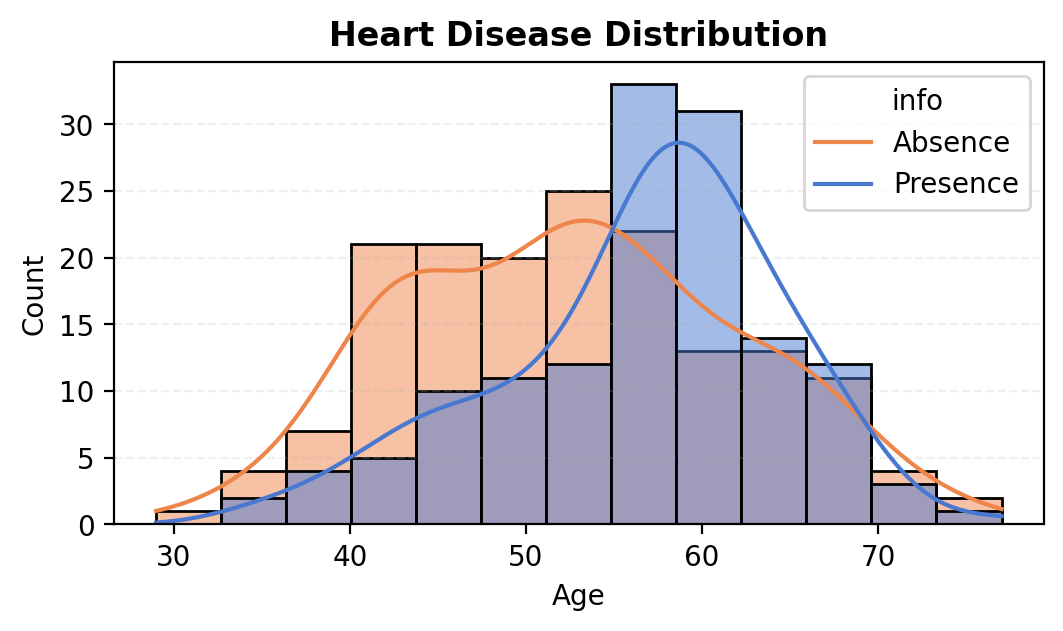

In [15]:
plt.figure(dpi=200,figsize=(6,3))
sns.histplot(data=df1, x="age",hue="target",kde=True,palette="muted")
plt.legend(title="info",labels=['Absence','Presence'])
plt.xlabel('Age')
plt.title("Heart Disease Distribution",fontweight="bold")
plt.grid(axis='y',alpha=0.2,linestyle="--")

in this part i wanted to modify the target collumn but i changed my mind because this is a medical data

In [16]:
def target_modifier(df,col,low,high):
    data=df.copy()
    for i in data:
        if i == col:
            for value in data[col]:
                if low <= value <=high:
                    pass
                elif value > high:
                    data["target"]=1
                elif value < low and data["target"] == 1:
                    data["target"] = 0
    return data
                

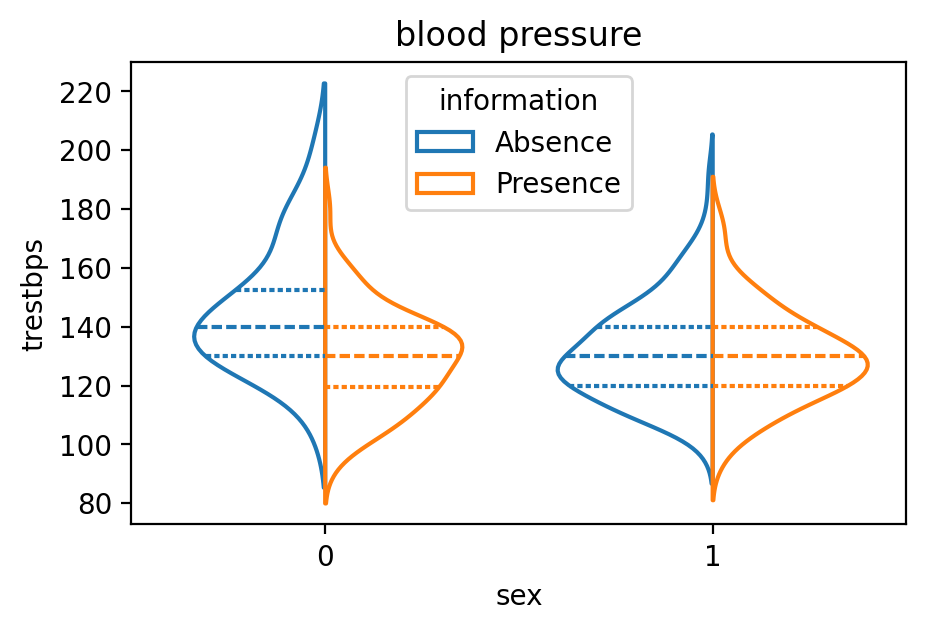

In [17]:
plt.figure(dpi=200,figsize=(5,3))
ax = sns.violinplot(data=df1,x="sex",y="trestbps",hue="target",split=True,fill=False,inner="quart")
ax.set_title("blood pressure")
handles, labels=ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=['Absence','Presence'],title="information")


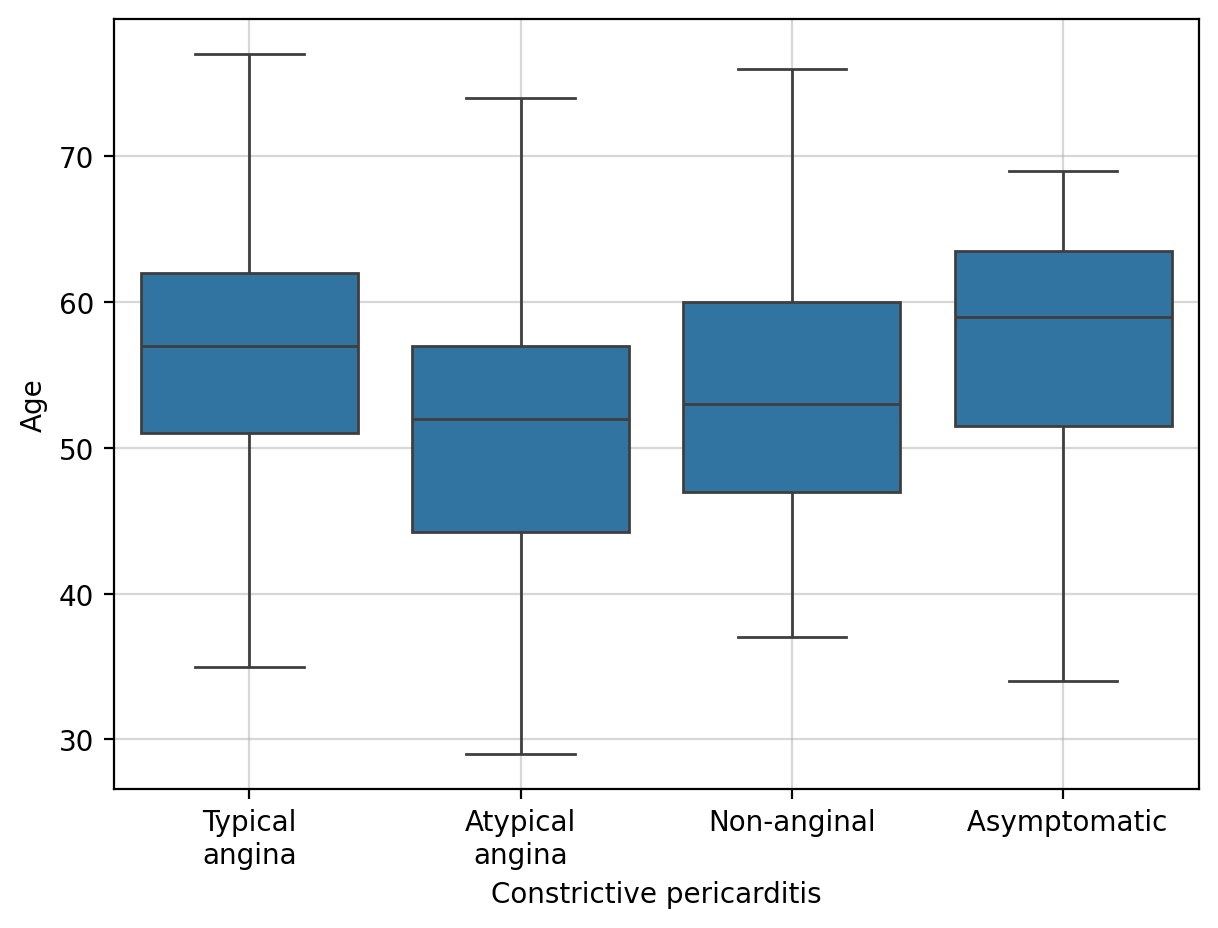

In [18]:
plt.figure(dpi=200,figsize=(7,5))
sns.boxplot(data=df1,x="cp",y="age")
plt.xlabel("Constrictive pericarditis")
plt.ylabel("Age")
plt.xticks([0,1,2,3],["Typical\nangina","Atypical\nangina","Non-anginal"," Asymptomatic"])
plt.grid(True,alpha=0.5)

Text(0.5, 1.0, 'Cholestrol Relation With Age ')

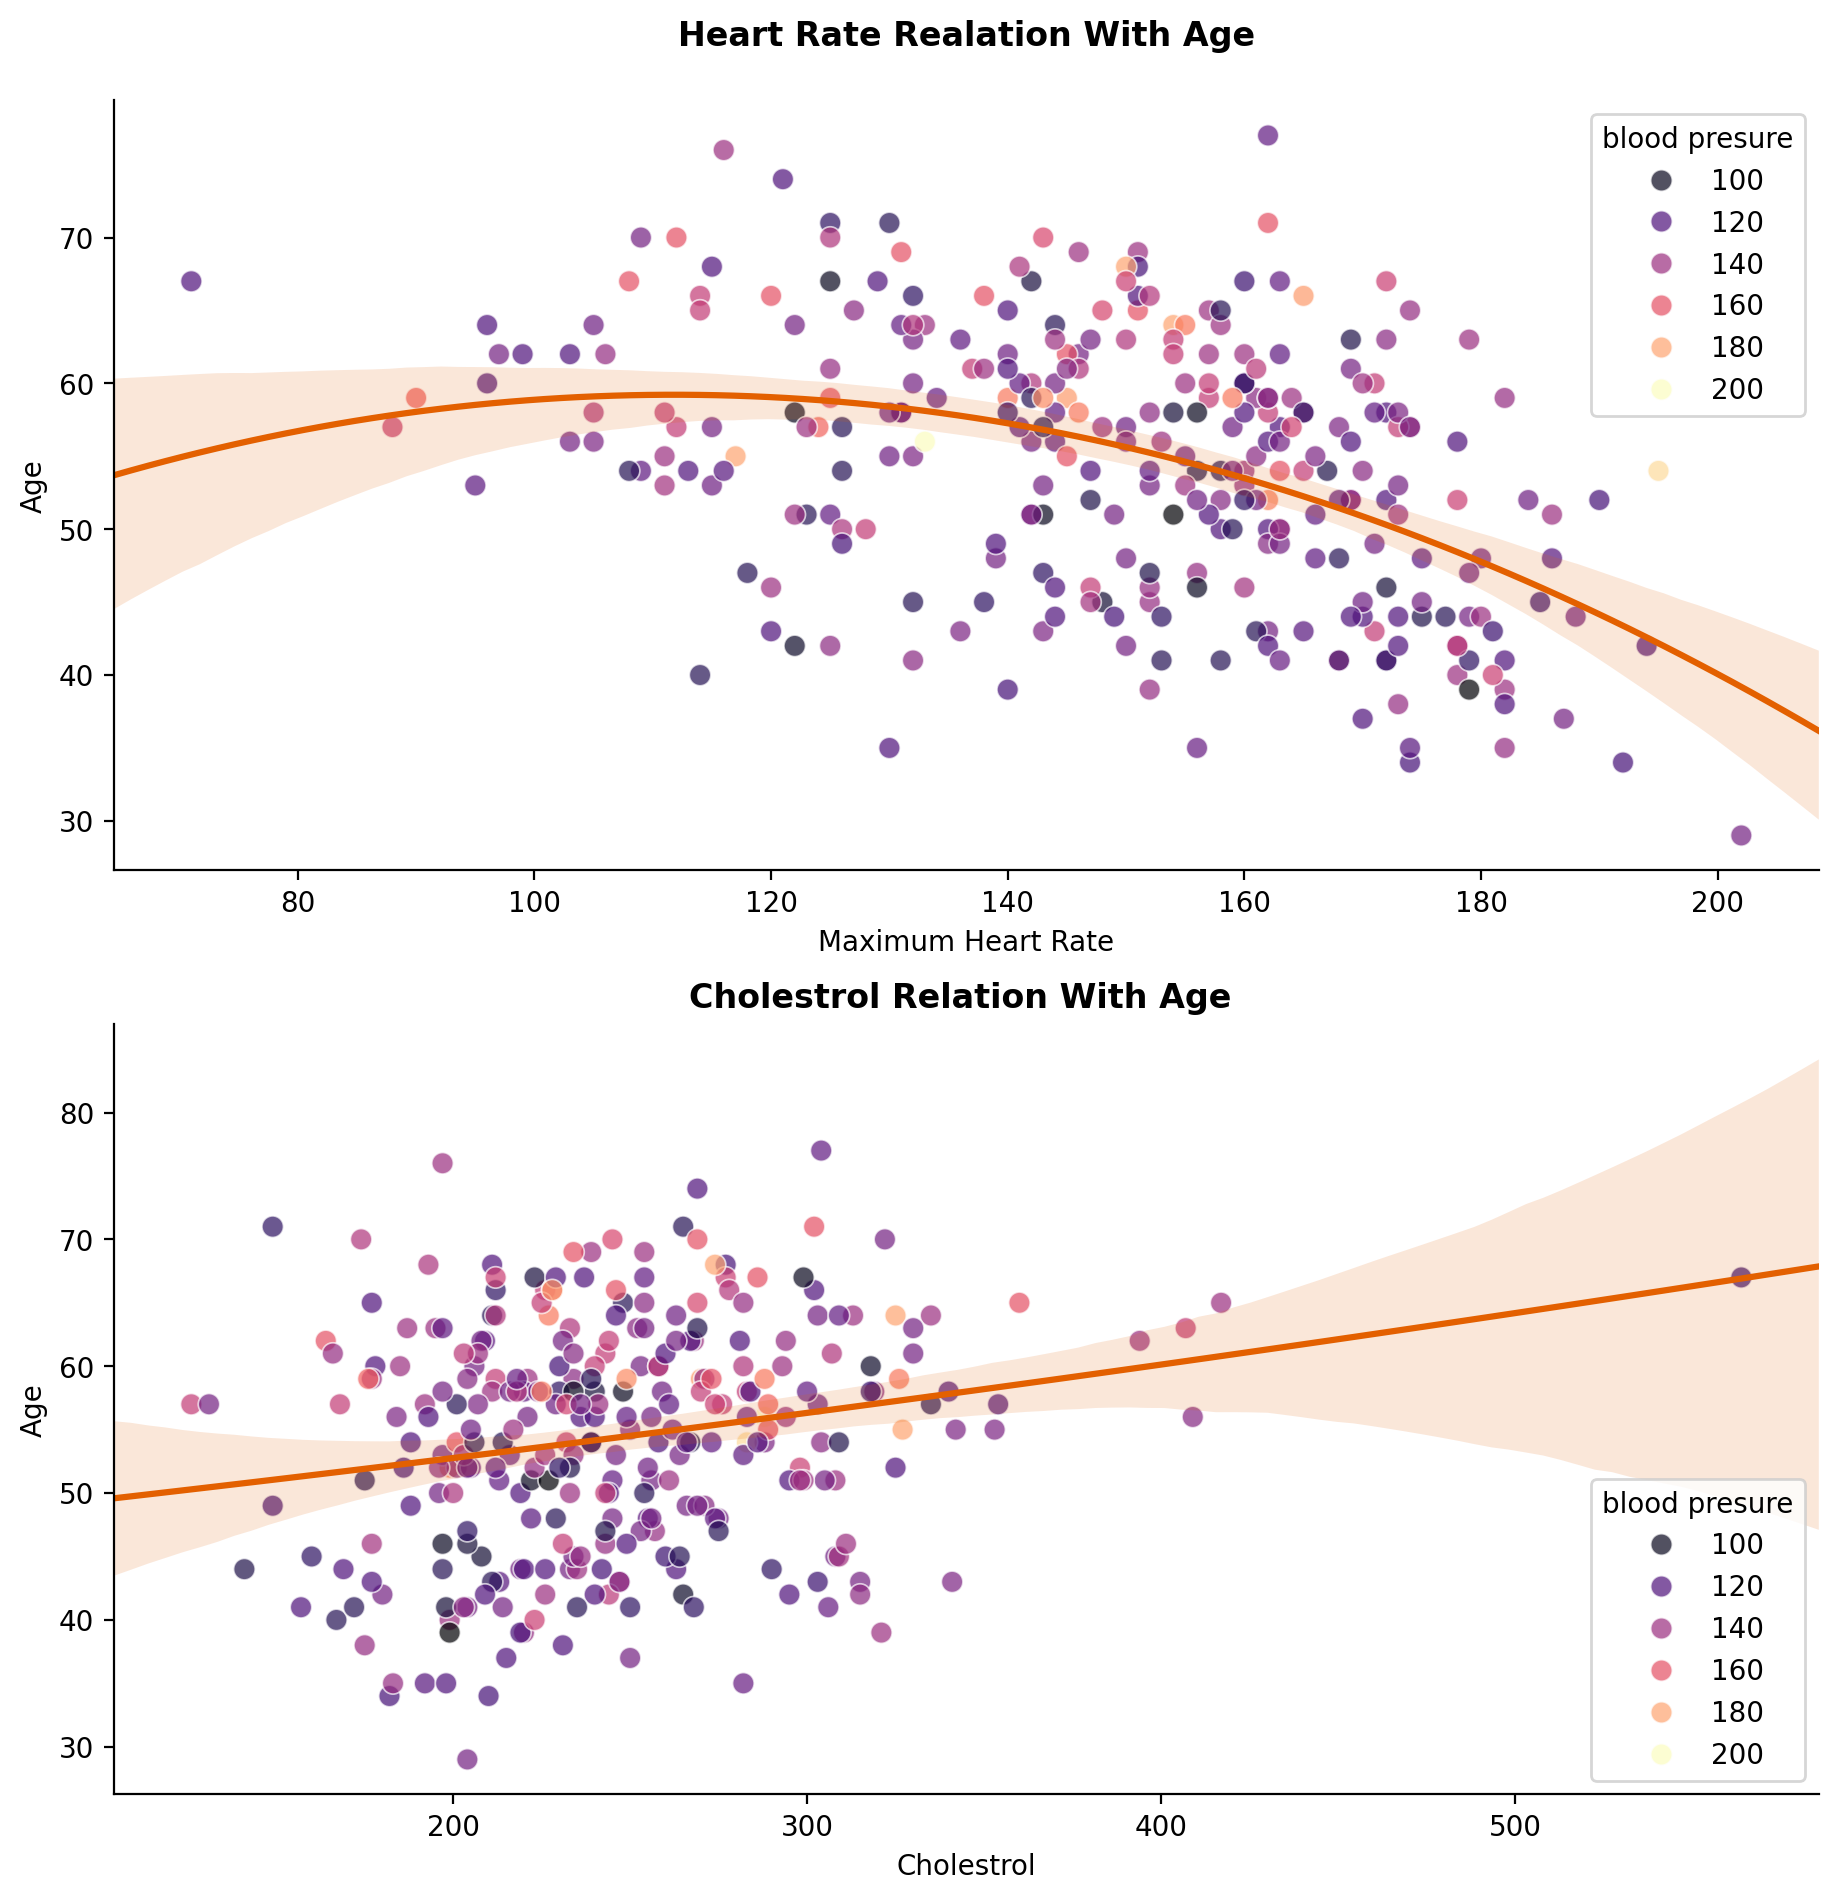

In [22]:
fig,axs=plt.subplots(2,1,dpi=200,figsize=(11,11))
sns.despine(fig, left=False, bottom=False)

sns.scatterplot(data=df1,x="thalach",y="age",hue="trestbps",s=60,alpha=0.7,palette="magma",ax=axs[0])
sns.regplot(data=df1, x="thalach", y="age",scatter=False, truncate=False, order=2,ax=axs[0],color="#E36000")
axs[0].legend(title="blood presure")
axs[0].set_ylabel("Age")
axs[0].set_xlabel("Maximum Heart Rate")
axs[0].legend(title="blood presure")
axs[0].set_title("Heart Rate Realation With Age\n",fontweight="bold")

sns.scatterplot(data=df1,x="chol",y="age",hue="trestbps",s=60,alpha=0.7,palette="magma",ax=axs[1])
sns.regplot(data=df1, x="chol", y="age",scatter=False, truncate=False, order=2,ax=axs[1],color="#E36000")
axs[1].legend(title="blood presure")
axs[1].set_ylabel("Age")
axs[1].set_xlabel("Cholestrol")
axs[1].legend(title="blood presure",loc="lower right")
axs[1].set_title("Cholestrol Relation With Age ",fontweight="bold")




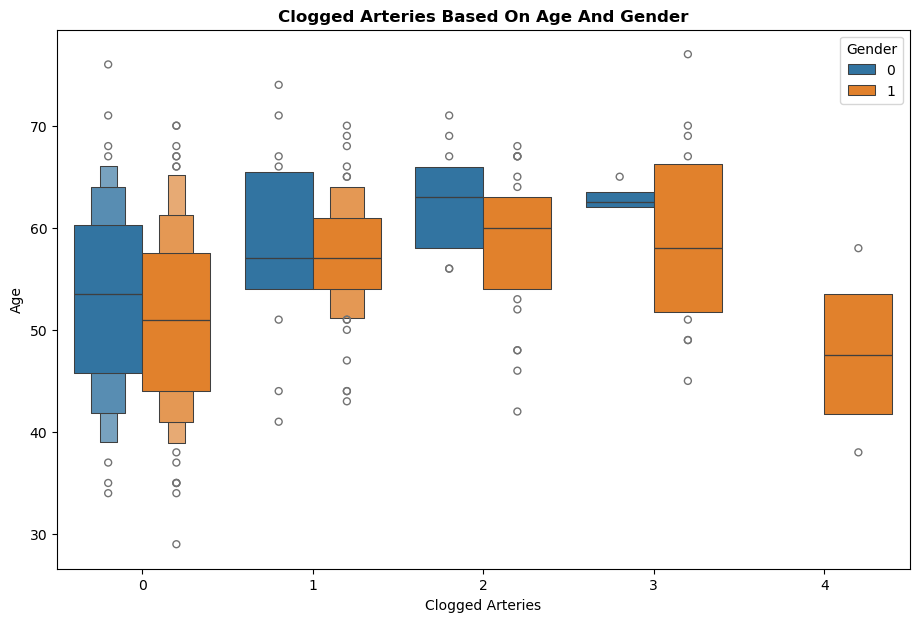

In [20]:
plt.figure(figsize=(11,7))
sns.boxenplot(data=df1,x="ca",y="age",hue="sex")
plt.legend(title="Gender")
plt.ylabel("Age")
plt.xlabel("Clogged Arteries")
plt.title("Clogged Arteries Based On Age And Gender",fontweight="bold")
plt.show()

Text(0.5, 1.0, 'ST Segment Shift Chest Paine during exercise Test ')

<Figure size 1000x800 with 0 Axes>

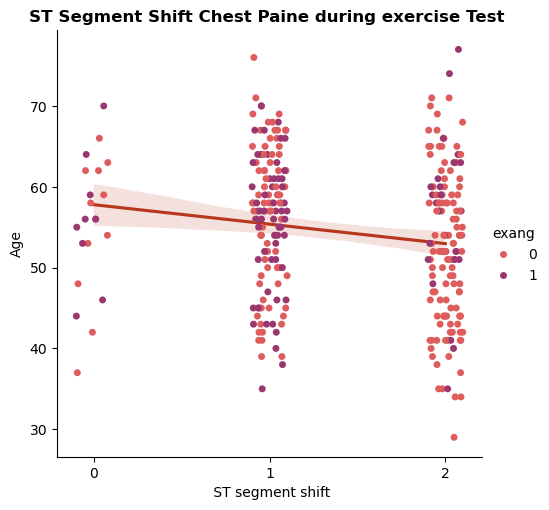

In [21]:
plt.figure(figsize=(10,8))
ax=sns.catplot(data=df1,x="slope",y="age",hue="exang",palette="flare")
sns.regplot(data=df1,x="slope",y="age",scatter=False,color="#B8361C")
plt.ylabel("Age")
plt.xlabel(" ST segment shift")
plt.title("ST Segment Shift Chest Paine during exercise Test ",fontweight="bold")